# Prediction of vehicle prices from multiple features

## Task
Using linear regression, create a model to predict the price of a used car. 

Start by trying to estimate the vehicle price based on mileage only. Implement three different versions to evaluate the model:
1. simple split into training and test data set
1. k-fold cross-validation without using the function `cross_val_score()`.
1. k-fold cross validation using the function `cross_val_score()`

In the next step, determine a reasonable combination of features that solve the problem. Which combination works best? Limit yourself to numeric values and use K-fold cross-validation for evaluation.

Note: Visualize the score for each of the cross-validations using a box-whisker plot

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("DataSets/autos_prepared.csv")
#df = pd.read_csv("DataSets/autos.csv", encoding = "ISO-8859-1")
#df = pd.read_excel("DataSets/autos.xlsx")

In [2]:
df.head()

,price,yearOfRegistration,powerPS,kilometer,model,fuelType,name
0,1450,1997,75,90000,andere,benzin,Toyota_Toyota_Starlet_1._Hand__TÜV_neu
1,13100,2005,280,5000,golf,benzin,R32_tauschen_oder_kaufen
2,4500,2008,87,90000,yaris,benzin,Toyota_Yaris_1.3_VVT_i
3,6000,2009,177,125000,3er,diesel,320_Alpinweiss_Kohlenstoff
4,3990,1999,118,90000,3er,benzin,BMW_318i_E46_+++_1._Hand_+++_Liebhaberfahrzeug


Simple Split Score: 0.017058127945146495


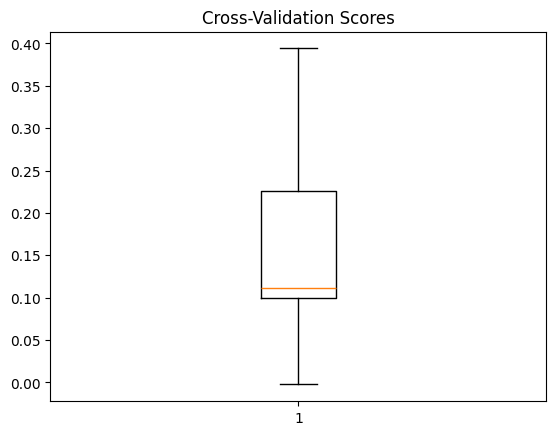

In [3]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression

# প্রথম অংশের জন্য ইনপুট ও আউটপুট নির্ধারণ
X_mileage = df[['kilometer']]
y = df['price']

# ১. সাধারণ ট্রেন-টেস্ট স্প্লিট
X_train, X_test, y_train, y_test = train_test_split(X_mileage, y, test_size=0.2, random_state=42)
model = LinearRegression().fit(X_train, y_train)
print("Simple Split Score:", model.score(X_test, y_test))

# ৩. cross_val_score ব্যবহার করে K-fold (উদাহরণস্বরূপ 5-fold)
model_cv = LinearRegression()
scores = cross_val_score(model_cv, X_mileage, y, cv=5)

# বক্সপ্লট দিয়ে ভিজ্যুয়ালাইজেশন
plt.boxplot(scores)
plt.title('Cross-Validation Scores')
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=1e91bd54-be52-46c8-8e4a-baf88d675b91' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>